# Limpiando dataset
En este cuaderno se hará la limpieza de los datos del dataset Buzon.

*Jonatan Bustillos Cruz*

*Gutiérrez Sánchez Angélica*


### 1. Cargar los datos

Advertencia: Ya existe un DataFrame con el nombre 'datasetBuzon.csv'.

=== Mostrando información general ===
Archivo:  datasetBuzon.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 12 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Marca temporal                                   320 non-null    object 
 1   Tipo de registro                                 320 non-null    object 
 2   Procedimiento o proceso en el que se le atendió  320 non-null    object 
 3   Servicios referidos (Detalle)                    320 non-null    object 
 4   Detalles de la queja, sugerencia o felicitación  320 non-null    object 
 5   Departamento que lo atendió                      220 non-null    object 
 6   Instancia                                        127 non-null    object 
 7   Unnamed: 7                                       0 n

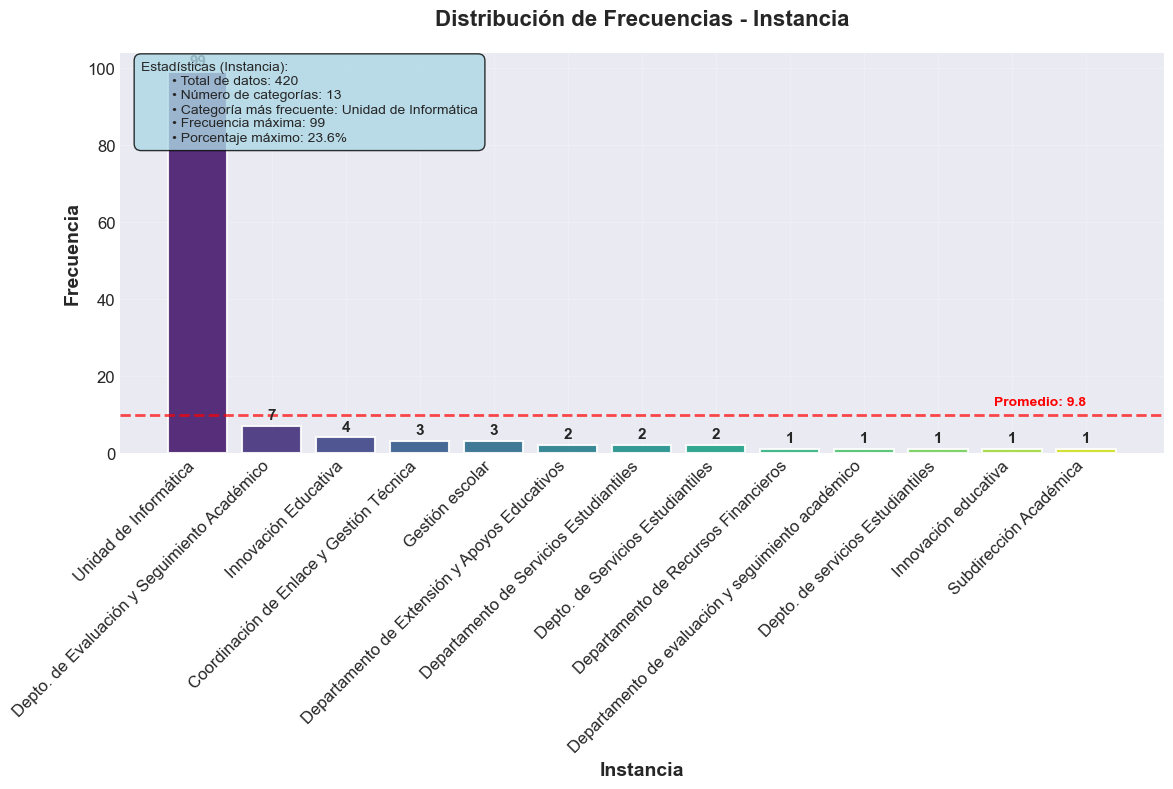


RESUMEN DE FRECUENCIAS - INSTANCIA
Unidad de Informática     |     99 ( 23.6%)
Depto. de Evaluación y Se |      7 (  1.7%)
Innovación Educativa      |      4 (  1.0%)
Coordinación de Enlace y  |      3 (  0.7%)
Gestión escolar           |      3 (  0.7%)
Departamento de Extensión |      2 (  0.5%)
Departamento de Servicios |      2 (  0.5%)
Depto. de Servicios Estud |      2 (  0.5%)
Departamento de Recursos  |      1 (  0.2%)
Departamento de evaluació |      1 (  0.2%)
Depto. de servicios Estud |      1 (  0.2%)
Innovación educativa      |      1 (  0.2%)
Subdirección Académica    |      1 (  0.2%)
Total                     |    420 (100.0%)

=== Mostrando información general ===
Archivo:  comentarios
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 2 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Detalles de la queja, su

In [9]:
# Clase especializada en las funciones de manejo de datos
from source.datos import CoordinadorDatos
from pathlib import Path
# Ruta genérica de los datos
PROJECT_ROOT = Path.cwd() # proyecto/source/constantes.py -> proyecto/
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"


admin_datos = CoordinadorDatos()
admin_datos.cargar_datos(DATA_RAW / "datasetBuzon.csv")
admin_datos.mostrar_datos()
admin_datos.filtrar_columnas_y_almacenar(
    ["Detalles de la queja, sugerencia o felicitación", 'Tipo de registro'],
    'comentarios'                                         
)
admin_datos.visualizador.mostrar_info()
admin_datos.visualizador.mostrar_primeros_datos()

### 2. Limpiar los datos
Nota: las implementaciones están en /source/preprocesamiento.py

In [10]:
from source.datos import VisualizadorDatos, Data
from source.preprocesamiento import PreprocesadorTextoAvanzado
import pandas as pd

# Obtener comentarios del almacén
comentarios = admin_datos.almacen.obtener_datos('comentarios')

# Verificar datos originales
visualizador = VisualizadorDatos(comentarios)
print("=== DATOS ORIGINALES ===")
visualizador.mostrar_info()

# Obtener dataframe y limpiar filas vacías iniciales
comentarios_data = comentarios.data.dropna().reset_index(drop=True)
print(f"\nFilas después de eliminar vacíos: {len(comentarios_data)}")

# Configurar preprocesador
preprocesador = PreprocesadorTextoAvanzado(idioma_spacy="es_core_news_sm")

# Nombre de la columna
columna_objetivo = 'Detalles de la queja, sugerencia o felicitación'

# Procesar usando el método integrado
print("\n=== INICIANDO PROCESAMIENTO ===")
df_procesado = preprocesador.procesar_dataframe(
    df=comentarios_data,
    columna_texto=columna_objetivo,
    inplace=False,
    a_minusculas_flag=True,
    quitar_acentos_flag=True,
    quitar_puntuacion_flag=True,
    quitar_numeros_flag=True,
    quitar_lineas_repetidas_flag=True,
    quitar_saltos_linea_flag=True,
    tokenizar_flag=True,
    quitar_stopwords_flag=True,
    lematizar_flag=True,
    devolver_como_string=True,
    limpiar_vacios_flag=True
)

print(f"Procesamiento completado. Shape: {df_procesado.shape}")

# Función para verificar si un texto está vacío después del procesamiento
def es_texto_valido(texto):
    """Verifica si el texto procesado es válido (no vacío, no solo espacios y mayor a cinco caracteres)"""
    if pd.isna(texto):
        return False
    if isinstance(texto, str):
        texto_limpio = texto.strip()
        con_texto = len(texto_limpio) > 0 and texto_limpio != ''

        cortas_validas = {'ok', 'si', 'no', 'bien', 'mal'}

        if con_texto and (len(texto_limpio) > 5 or texto_limpio in cortas_validas):
            return True
    return False

# Limpiar filas con textos vacíos o inválidos
print("\n=== LIMPIEZA POST-PROCESAMIENTO ===")
print(f"Filas antes de limpieza: {len(df_procesado)}")

# Filtrar textos válidos
df_limpio = df_procesado[
    df_procesado[columna_objetivo].apply(es_texto_valido)
].reset_index(drop=True)

print(f"Filas después de limpieza: {len(df_limpio)}")
print(f"Filas eliminadas (vacías/inválidas): {len(df_procesado) - len(df_limpio)}")

# Mostrar ejemplos de textos procesados
print("\n=== MUESTRA DE TEXTOS PROCESADOS ===")
for i in range(min(3, len(df_limpio))):
    texto = df_limpio[columna_objetivo].iloc[i]
    print(f"\nTexto {i+1}:")
    print(f"  Longitud: {len(texto)} caracteres")
    print(f"  Contenido: {texto[:200]}{'...' if len(texto) > 200 else ''}")

# Crear objeto Data
dataset_preprocesado = Data(df_limpio, nombre="Comentarios Preprocesados")

# Verificar que no esté vacío
if dataset_preprocesado.data.empty:
    print("\n⚠️ ERROR: El dataset procesado está vacío. Verifica el procesamiento.")
else:
    print(f"\n✓ Dataset procesado correctamente: {len(dataset_preprocesado.data)} filas")
    
    # Actualizar visualizador
    visualizador.agregar_nuevos_datos(dataset_preprocesado)
    print("\n=== DATOS PROCESADOS FINALES ===")
    visualizador.mostrar_info()
    
    # Agregar al almacén
    admin_datos.almacen.agregar_datos(dataset_preprocesado)
    
    # Guardar archivo
    resultado = admin_datos.almacen.guardar_datos("Comentarios Preprocesados", DATA_PROCESSED)
    
    if resultado:
        print(f"\n✓ Archivo guardado en: {DATA_PROCESSED / 'Comentarios Preprocesados.csv'}")
        
        # Verificación del archivo guardado
        import pandas as pd
        df_verificacion = pd.read_csv(DATA_PROCESSED / "Comentarios Preprocesados.csv")
        print(f"Verificación - Filas en archivo: {len(df_verificacion)}")
    else:
        print("\n⚠️ Error al guardar el archivo")

=== DATOS ORIGINALES ===

=== Mostrando información general ===
Archivo:  comentarios
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 2 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Detalles de la queja, sugerencia o felicitación  320 non-null    object
 1   Tipo de registro                                 320 non-null    object
dtypes: object(2)
memory usage: 6.7+ KB
None

Filas después de eliminar vacíos: 320

=== INICIANDO PROCESAMIENTO ===
Procesamiento completado. Shape: (320, 2)

=== LIMPIEZA POST-PROCESAMIENTO ===
Filas antes de limpieza: 320
Filas después de limpieza: 228
Filas eliminadas (vacías/inválidas): 92

=== MUESTRA DE TEXTOS PROCESADOS ===

Texto 1:
  Longitud: 31 caracteres
  Contenido: funcionar computadora falta red

Texto 2:
  Longitud: 9 caracteres
  Contenido: felicidad

Texto 3:
  Longitud: 53 cara

### 3. Acorde con las características del dataset, determina las herramientas que te apoyarán en el entrenamiento del modelo clasificador SIN utilizar algún LLM (justifica cada aspecto):
a. Etiquetado el dataset (¿Consideras un etiquetado manual o programar un etiquetador automático?) *Al ser muy pocos comentarios, el etiquetado manual es lo más viable y preciso.*

b. Balanceo de Clases (¿contemplas el uso de alguna estrategia de balanceo? oversampling, undersampling, generación de datos sintéticos) *Será mucho mejor los datos sintéticos si se quiere entrenar con datos balanceados*

c. Modelo de Espacio Vectorial (td-idf, embeddings,...): *En el pasado funcionó muy bien TF-IDF, así que lo usaré otra vez.*

d. ¿Consideras algún otro tratamiento adicional que te ayude a identificar palabras clave o relevantes? P. ej. LSA, PCA: *No lo considero, puesto que el dataset es pequeño y la longitud individual de los textos también.*

e. Modelo Clasificador (¿Qué modelo clasificador de los vistos en clase consideras adecuado y por qué?) *Consideraría Random Forest, puesto que convertiremos el problema a uno supervisado, siendo este de los mejores en ese campo.* 